#**Data Understanding**

##**Carga del Dataset**

In [2]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(url, header=None, names=column_names, na_values=" ?")

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##Explorando el Dataset

In [3]:
df.shape

(32561, 15)

35,561 observaciones y 15 variables

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Variables numéricas**: age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week

**Variables categóricas**: workclass, education, marital_status, occupation, relationship, race, sex, native_country

**Variable objetivo**: income (se tratará como binaria)

##Estadísticos Descriptivos

In [5]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Datos relevantes:

*   La fila "count" demuestra que en estas variables (numéricas) no hay faltantes de datos (32,561 registros)
*   La edad media es de 38.5 años
*   El trabajador más joven tiene 17 años y el mayor 90 años.
*   El 75% de las personas tienen 48 años o menos, lo que indica que es una población mayoritariamente joven-adulta.




##Análisis de la Variable Objetivo

Esto es para analizar el balance del dataset, es decir, encontrar la proporción

In [6]:
df["income"].value_counts()
df["income"].value_counts(normalize=True)

,proportion
income,
<=50K,0.75919
>50K,0.24081


Ahora se analizan los valores faltantes.

In [7]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


Variables con valores faltantes: workclass, occupation, native_country

##Análisis Exploratorio Visual

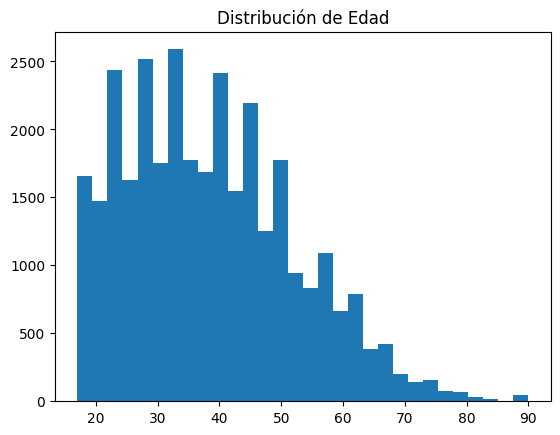

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30)
plt.title("Distribución de Edad")
plt.show()

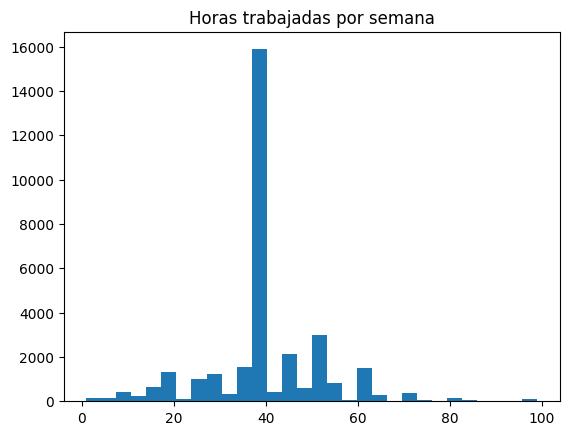

In [9]:
plt.hist(df["hours_per_week"], bins=30)
plt.title("Horas trabajadas por semana")
plt.show()

Correlación entre variables numéricas

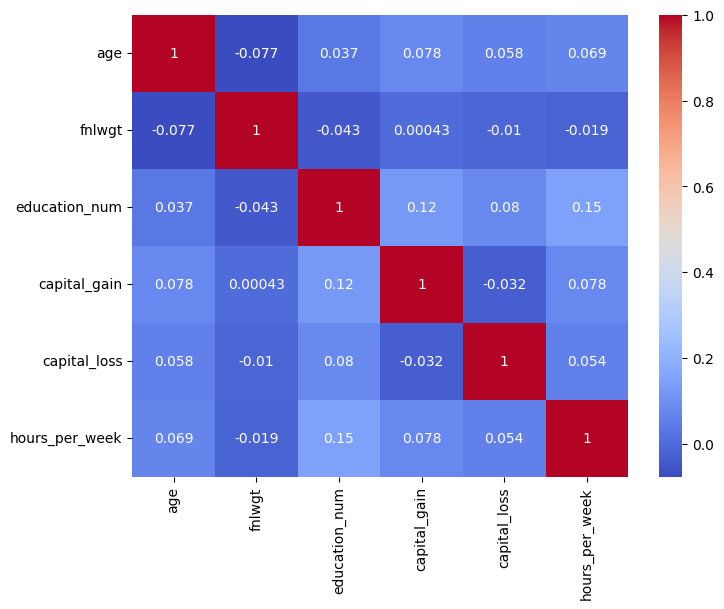

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

* La Relación Educación vs. Horas de Trabajo (0.15): Es la correlación positiva más "alta" (aunque débil). Sugiere que las personas con más años de educación (education_num) tienden a trabajar un poco más de horas por semana.

* La Relación Educación vs. Ganancia de Capital (0.12): Existe una ligera tendencia a que a mayor nivel educativo, mayores sean las ganancias de capital.

###En resumen...

* Se observa que la variable capital_gain presenta fuerte asimetría positiva.
* La variable education_num muestra correlación positiva con income (A mayor nivel educativo → mayor probabilidad de ingreso >50K).
* El dataset presenta leve desbalance en la variable objetivo.
* Existen valores faltantes en variables categóricas que deberán tratarse en la fase de preparación.

#**Data Preparation**

##Tratamiento de valores faltantes

In [11]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


Con esto, los NA de este dataset, los cuales aparecen como " ?",  se convierten a na_values=" ?".

Eliminación de los registros con NA, ya que el porcentaje de NA es bajo (~5%) y no afecta representatividad

In [12]:
df = df.dropna()

##Limpieza

Ahora se procede a hacer limpieza en la variable objetivo, esto nos ayudará a evitar errores de codificación posteriores

In [13]:
df["income"] = df["income"].str.strip()

##Codificación

Codificación de la variable objetivo...
1 = ingreso alto
0 = ingreso bajo

In [14]:
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

##Separación

Separación de Variables Predictoras y Objetivo

In [15]:
X = df.drop("income", axis=1)
y = df["income"]

##Codificación

Codificación de Variables Categóricas, a través de One-Hot. Se utiliza este método para convertir variables categóricas en numéricas, ya que los algoritmos de clasificación requieren variables cuantitativas.

In [16]:
X = pd.get_dummies(X, drop_first=True)

Para poder utilizar los siguientes modelos:
*   KNN
*   SVM
*   Regresión Logística
Es necesario hacer escalamiento de variables

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Además, también se aplica una estandarización debido a que algunos algoritmos son sensibles a la escala de las variables.

##División Training / Validation / Test

Finalmente, se aplica la división Train / Validation / Test  con la siguiente estructura:
* 70% Training
* 15% Validation
* 15% Test




In [18]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

Nota: el uso de stratify=y mantiene proporción de clases.

##Verificación

Y se procede a la verificación final...

In [19]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (21113, 96)
Validation: (4524, 96)
Test: (4525, 96)


#**Modeling**

Aplicación de modelos a comparar...
* Regresión Logística
* k-NN
* Random Forest
* AdaBoost
* SVM

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "k-NN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results.append([
        name,
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred)
    ])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.852564,0.730191,0.646536,0.685822
3,AdaBoost,0.850796,0.749723,0.601243,0.667324
4,SVM,0.845933,0.739665,0.587922,0.655121
0,Logistic Regression,0.844385,0.718880,0.615453,0.663158
1,k-NN,0.813882,0.637066,0.586146,0.610546


#**Evaluation**

Evaluación en Entrenamiento vs Prueba, aquí se verificará si el modelo generaliza bien.

In [22]:
from sklearn.metrics import accuracy_score

# Identificar el mejor modelo basado en la precisión en el conjunto de validación
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

# Entrenar el mejor modelo si no se ha hecho, o asegurarse de que usa el modelo entrenado
# Si el modelo ya está entrenado (como en el bucle anterior), no es necesario volver a entrenar aquí.
# Sin embargo, para la predicción en el conjunto de prueba, necesitamos su predicción.
# Se asume que `y_test_pred` también necesita ser generado usando `best_model`

# Accuracy en entrenamiento
y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Accuracy en prueba
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Accuracy Train:", train_acc)
print("Accuracy Test:", test_acc)

Accuracy Train: 1.0
Accuracy Test: 0.8495027624309393


Se tiene una buena capacidad de generalización y no se observa sobreajuste.

#**Deployment**